# BBM418 / AIN433 — Fundamentals of Computer Vision  
## Programming Assignment 2: Object Localization and Single-Object Tracking

### Student Notebook

This notebook is the starter template for the assignment. This is a draft.
You can follow the given structure or you can implement your version.
Feel free to change given code templates.

The assignment has five main parts:

1. Dataset loading and visualization  
2. Search-region sample generation  
3. CNN-based bounding-box regression model  
4. Single-object tracking on validation and test sequences  
5. Validation evaluation and analysis  

Keep your implementation clean, reproducible, and easy to follow.

### Student Info

#### Name: Hayrunnisa Çiko

#### ID: 2220356043

In [ ]:
!git clone https://github.com/nisaciko/cv-ass2.git /content/cv-ass2 2>/dev/null || echo "already cloned"
%cd /content/cv-ass2

## Assignment Setting

You will work with the given single-object tracking dataset.

### Training and Validation Sequences

These contain full ground-truth annotations:

```text
SequenceName/
  img/
    0001.jpg
    0002.jpg
    ...
  groundtruth_rect.txt
```

### Test Sequences

These contain only the first-frame initialization box:

```text
SequenceName/
  img/
    0001.jpg
    0002.jpg
    ...
  init_rect.txt
```

## Important Rule

For validation and test tracking, you may use only the first-frame bounding box to initialize the tracker.

After the first frame, all bounding boxes must be predicted by your tracker.

For validation sequences, later ground-truth boxes may be used **only after tracking** to compute evaluation metrics.

For test sequences, ground truth is hidden and must not be used.

## Expected Output

Your notebook should generate prediction CSV files for the test sequences.

Each file must be saved as:

```text
outputs/test/<sequence_name>_predictions.csv
```

The required CSV format is:

```text
frame,x,y,w,h
1,198,214,34,81
2,197.2,214.1,34.5,80.7
3,195.4,213.9,34.8,81.2
```

Coordinates must be full-frame pixel coordinates in `(x, y, width, height)` format. Do **not** save normalized crop coordinates.

# 0. Imports and Configuration

Run this section first. You may add extra imports if needed.

Make sure the paths below match your local folder structure.

In [ ]:
import os
import csv
import math
import random
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms


In Google Colab environment, to download the dataset and extract it to the working directory you may use the following cell.

In [ ]:
# Download the dataset on Colab; skip on a local machine where it's already present.
import os

if not os.path.exists("data") and not os.path.exists("dataset/data"):
    # This FILE_ID refers to the dataset uploaded to my own Drive, to avoid
    # the public gdown access-quota errors.
    FILE_ID = '1hJmKhPzHdJWzhCdU6oaAePFxAdz3NJoc'
    ZIP_NAME = 'dataset.zip'
    !gdown --id {FILE_ID} -O {ZIP_NAME}
    !unzip -q {ZIP_NAME} -d .
    !rm {ZIP_NAME}
    print("Dataset downloaded and extracted.")
else:
    print("Dataset already present; skipping download.")


Dataset already present; skipping download.


## Reproducibility

Set random seeds so your results are more reproducible.
Include your seeds if you introduce additional randomness.

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Speed > strict bit-reproducibility for the experimentation phase.
# benchmark=True lets cuDNN pick the fastest kernels for our input shapes;
# deterministic=False allows non-deterministic algos for that speed.
# Results still seeded, just match within ~0.01 IoU run-to-run.
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True


## Paths and Hyperparameters

Update `DATA_ROOT` if your dataset is located somewhere else.

The suggested hyperparameters are only starting points. You may change them, but report your final choices in the discussion section.

In [ ]:
# Default to the local layout: dataset/data/sequences and dataset/data/splits.
# Falls back to Colab layout (data/sequences) if that's what is present.
DATA_ROOT = Path("dataset/data/sequences")
SPLIT_ROOT = Path("dataset/data/splits")
if not DATA_ROOT.exists() and Path("data/sequences").exists():
    DATA_ROOT = Path("data/sequences")
    SPLIT_ROOT = Path("data/splits")

OUTPUT_ROOT = Path("outputs")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / "test").mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / "validation").mkdir(parents=True, exist_ok=True)
CHECKPOINT_ROOT = Path("checkpoint")
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 224
SEARCH_SCALE = 2.5
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
NUM_WORKERS = 2 if DEVICE.type == "cuda" else 0

# ImageNet normalization constants — used both for the training Dataset
# and for tracking-time preprocessing, so they live here in one place.
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

print("Device:    ", DEVICE)
print("DATA_ROOT: ", DATA_ROOT, "exists:", DATA_ROOT.exists())
print("SPLIT_ROOT:", SPLIT_ROOT, "exists:", SPLIT_ROOT.exists())


Device:     cuda
DATA_ROOT:  dataset/data/sequences exists: True
SPLIT_ROOT: dataset/data/splits exists: True


# PART 1 — Dataset Loading and Visualization

In this part, you will implement utilities for loading the dataset and visualizing bounding boxes.

You need separate loading functions for:

- training/validation sequences with `groundtruth_rect.txt`,
- test sequences with `init_rect.txt`.

This distinction is important because test sequences do not contain full ground truth.

## 1.1 Bounding-Box File Reader

The annotation files contain bounding boxes in the format:

```text
x,y,width,height
```

Some files may use commas, spaces, or tabs as separators. Your parser should handle these cases.

In [ ]:
def read_bbox_file(path: Path) -> np.ndarray:
    """Read a bbox annotation file.

    Each non-empty line contains: x, y, width, height.
    Values may be separated by commas, tabs, or whitespace.

    Returns an (N, 4) float32 array.
    """
    boxes = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # Normalize all common separators to spaces, then split.
            for sep in [",", "\t", ";"]:
                line = line.replace(sep, " ")
            parts = [p for p in line.split() if p]
            if len(parts) < 4:
                continue
            boxes.append([float(parts[0]), float(parts[1]),
                          float(parts[2]), float(parts[3])])
    return np.asarray(boxes, dtype=np.float32)


## 1.2 Frame Path Reader

This function should read all frame paths from the `img/` folder and sort them in frame order.

In [ ]:
def get_frame_paths(sequence_path: Path) -> List[Path]:
    """Return sorted frame paths from sequence_path/img/."""
    img_dir = Path(sequence_path) / "img"
    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    paths = [p for p in img_dir.iterdir() if p.suffix.lower() in exts]
    # Filenames are zero-padded (0001.jpg, 0002.jpg, ...) so lexicographic
    # sort gives the correct frame order.
    return sorted(paths, key=lambda p: p.name)


## 1.3 Load Training / Validation Sequences

Training and validation sequences contain full ground truth.

Your loader must check that:

```text
number of frames == number of ground-truth boxes
```

If there is a mismatch, raise an error. Do not silently truncate frames or annotations.

In [ ]:
def load_sequence_with_gt(sequence_path: Path) -> Tuple[List[Path], np.ndarray]:
    """Load a training/validation sequence with full ground truth.

    Raises ValueError if the number of frames and the number of
    annotation rows do not match.
    """
    sequence_path = Path(sequence_path)
    frame_paths = get_frame_paths(sequence_path)
    gt_path = sequence_path / "groundtruth_rect.txt"
    bboxes = read_bbox_file(gt_path)
    if len(frame_paths) != len(bboxes):
        raise ValueError(
            f"Mismatch in {sequence_path.name}: "
            f"{len(frame_paths)} frames vs {len(bboxes)} bboxes"
        )
    return frame_paths, bboxes


## 1.4 Load Test Sequences

Test sequences contain only `init_rect.txt`.

This file contains one bounding box: the first-frame initialization box.

Your test loader should not expect `groundtruth_rect.txt`.

In [ ]:
def load_test_sequence(sequence_path: Path) -> Tuple[List[Path], np.ndarray]:
    """Load a test sequence: frames + the single first-frame init box."""
    sequence_path = Path(sequence_path)
    frame_paths = get_frame_paths(sequence_path)
    init_path = sequence_path / "init_rect.txt"
    bboxes = read_bbox_file(init_path)
    if len(bboxes) == 0:
        raise ValueError(f"No init bbox in {init_path}")
    return frame_paths, bboxes[0]


## 1.5 Image Reading and Drawing Utilities

Implement helper functions for reading RGB images and drawing bounding boxes.

These functions will be used throughout the notebook.

In [ ]:
def read_image_rgb(path: Path) -> np.ndarray:
    """Read an image with OpenCV and convert BGR -> RGB."""
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def draw_bbox(
    image: np.ndarray,
    bbox: np.ndarray,
    color: Tuple[int, int, int] = (0, 255, 0),
    thickness: int = 2,
    label: Optional[str] = None,
) -> np.ndarray:
    """Draw an (x, y, w, h) bbox on a copy of the given RGB image."""
    out = image.copy()
    x, y, w, h = [int(round(v)) for v in bbox]
    cv2.rectangle(out, (x, y), (x + w, y + h), color, thickness)
    if label is not None:
        cv2.putText(out, label, (x, max(0, y - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 1, cv2.LINE_AA)
    return out


def show_image(image: np.ndarray, title: str = "", figsize: Tuple[int, int] = (6, 4)):
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.axis("off")
    plt.title(title)
    plt.show()


## 1.6 Sequence Listing

This helper is useful for checking which sequences exist under `DATA_ROOT`.

In [ ]:
def list_sequences(data_root: Path) -> List[str]:
    """List subfolders of data_root that look like a sequence (have an img/ folder)."""
    data_root = Path(data_root)
    out = []
    for p in sorted(data_root.iterdir()):
        if p.is_dir() and (p / "img").is_dir():
            out.append(p.name)
    return out


## 1.7 Visualization Task

Visualize at least five frames from at least two training/validation sequences.

For each visualized frame, draw the ground-truth bounding box.

Found 57 sequences. First few: ['Basketball', 'Biker', 'Bird2', 'BlurBody', 'BlurCar1', 'BlurCar2', 'BlurCar3', 'BlurCar4']
Visualizing: ['Deer', 'Boy']


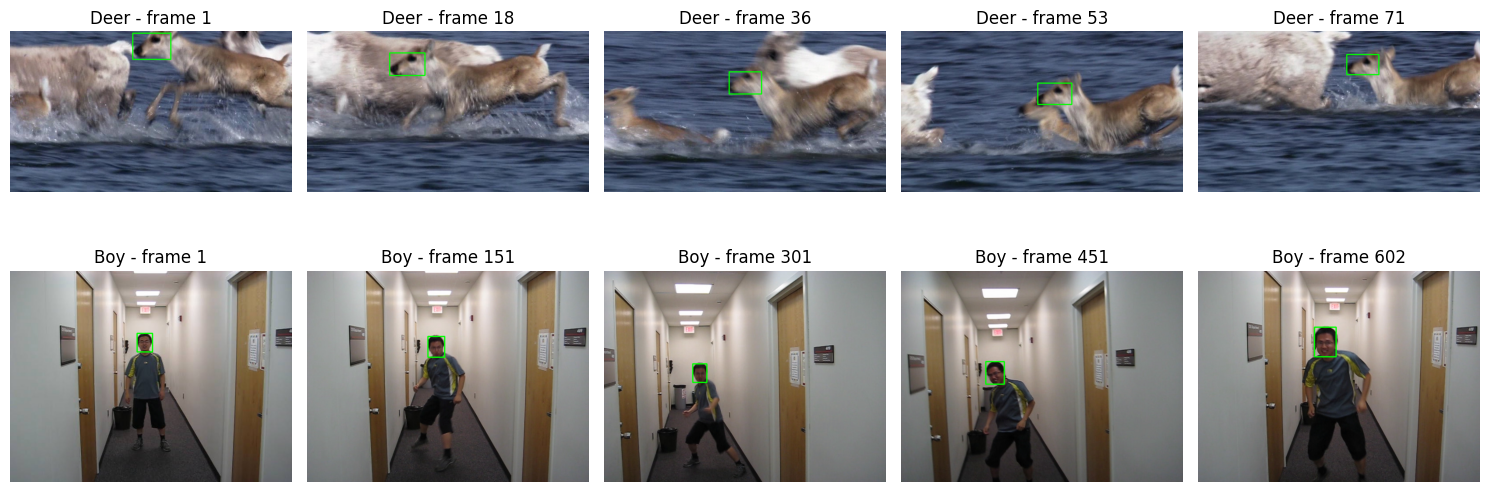

In [ ]:
# Quick sanity check: list a few available sequences.
_available = list_sequences(DATA_ROOT)
print(f"Found {len(_available)} sequences. First few:", _available[:8])

# Visualize 5 evenly-spaced frames from 2 different sequences,
# with the ground-truth bounding box drawn on each one.
def visualize_sample_frames(seq_names: List[str], frames_per_seq: int = 5):
    fig, axes = plt.subplots(len(seq_names), frames_per_seq,
                             figsize=(3 * frames_per_seq, 3 * len(seq_names)))
    if len(seq_names) == 1:
        axes = np.array([axes])
    for row, name in enumerate(seq_names):
        frames, gts = load_sequence_with_gt(DATA_ROOT / name)
        idxs = np.linspace(0, len(frames) - 1, frames_per_seq).astype(int)
        for col, fi in enumerate(idxs):
            img = read_image_rgb(frames[fi])
            img = draw_bbox(img, gts[fi], color=(0, 255, 0), thickness=2)
            ax = axes[row][col]
            ax.imshow(img)
            ax.set_title(f"{name} - frame {fi + 1}")
            ax.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / "part1_sample_frames.png", dpi=120)
    plt.show()

# Pick two visually-different sequences. Fall back to whatever is present.
_preferred = ["Deer", "Boy", "Couple", "BlurCar1", "Crossing"]
_demo_seqs = [s for s in _preferred if s in _available][:2]
if len(_demo_seqs) < 2:
    _demo_seqs = _available[:2]
print("Visualizing:", _demo_seqs)
visualize_sample_frames(_demo_seqs, frames_per_seq=5)


# Split Handling

The assignment uses fixed train/validation/test splits.

Use only the provided split files:

```text
splits/train.txt
splits/val.txt
splits/test.txt
```

Each file contains one sequence name per line.

## Split File Loading

Implement the functions below to read split files and verify that the sequence folders match the expected format.

In [ ]:
def read_split_file(split_path: Path) -> List[str]:
    """Read sequence names (one per line) from a split file."""
    with open(split_path, "r") as f:
        return [ln.strip() for ln in f if ln.strip()]


def load_splits(split_root: Path) -> Tuple[List[str], List[str], List[str]]:
    """Load train.txt, val.txt, test.txt from split_root."""
    split_root = Path(split_root)
    train = read_split_file(split_root / "train.txt")
    val = read_split_file(split_root / "val.txt")
    test = read_split_file(split_root / "test.txt")
    return train, val, test


def verify_split_files(
    data_root: Path,
    train_sequences: List[str],
    val_sequences: List[str],
    test_sequences: List[str],
):
    """Sanity check that the required annotation files exist for each sequence."""
    data_root = Path(data_root)
    missing = []
    for name in train_sequences + val_sequences:
        seq = data_root / name
        if not (seq / "groundtruth_rect.txt").is_file():
            missing.append(f"{name} (missing groundtruth_rect.txt)")
    for name in test_sequences:
        seq = data_root / name
        if not (seq / "init_rect.txt").is_file():
            missing.append(f"{name} (missing init_rect.txt)")
    if missing:
        print("WARNING: some sequences are missing expected files:")
        for m in missing:
            print(" -", m)
    else:
        print("All split sequences present with required annotation files.")


## Load Splits

Run this cell after implementing the split-loading functions.

In [ ]:
train_sequences, val_sequences, test_sequences = load_splits(SPLIT_ROOT)
print(f"train: {len(train_sequences)} | val: {len(val_sequences)} | test: {len(test_sequences)}")
verify_split_files(DATA_ROOT, train_sequences, val_sequences, test_sequences)

# Drop any sequences that aren't actually present on disk (defensive).
_present = set(list_sequences(DATA_ROOT))
train_sequences = [s for s in train_sequences if s in _present]
val_sequences   = [s for s in val_sequences   if s in _present]
test_sequences  = [s for s in test_sequences  if s in _present]
print(f"after presence filter -> "
      f"train: {len(train_sequences)} | val: {len(val_sequences)} | test: {len(test_sequences)}")


train: 39 | val: 11 | test: 7
All split sequences present with required annotation files.
after presence filter -> train: 39 | val: 11 | test: 7


# (Optional) Dataset Exploration

This section is not required for implementation, but it is helpful for understanding the dataset.

You may use these cells to inspect:

- sequence lengths,
- bounding-box size distribution,
- object trajectory,
- scale changes.

These visualizations can also help your discussions.

## (Optional) Dataset Summary

After loading the splits, summarize the number of frames and bounding-box sizes in the training and validation sets.

In [ ]:
# Optional: summarize frame counts and average bbox size per train/val sequence.
rows = []
for name in train_sequences + val_sequences:
    frames, gts = load_sequence_with_gt(DATA_ROOT / name)
    rows.append({
        "sequence": name,
        "split": "train" if name in train_sequences else "val",
        "num_frames": len(frames),
        "mean_w": float(np.mean(gts[:, 2])),
        "mean_h": float(np.mean(gts[:, 3])),
    })
_summary_df = pd.DataFrame(rows)
print(_summary_df.head(10).to_string(index=False))
print("Total train frames:", int(_summary_df[_summary_df.split == "train"].num_frames.sum()))
print("Total val frames:  ", int(_summary_df[_summary_df.split == "val"].num_frames.sum()))


 sequence split  num_frames     mean_w     mean_h
     Deer train          71  85.253525  56.253521
 Crossing train         120  16.716667  42.158333
      Boy train         602  34.142857  43.259136
     Car1 train        1020  25.351961  21.015686
 Walking2 train         500  22.945999  75.991997
     Doll train        3872  46.960228  97.453773
 BlurCar4 train         380 159.352631 143.573685
FleetFace train         707 131.097595 154.207916
 BlurCar3 train         357  86.173668  70.795517
   Matrix train         100  51.689999  60.020000
Total train frames: 26587
Total val frames:   5052


## (Optional) Bounding-Box Distribution

Plot distributions of bounding-box width, height, area, or aspect ratio.

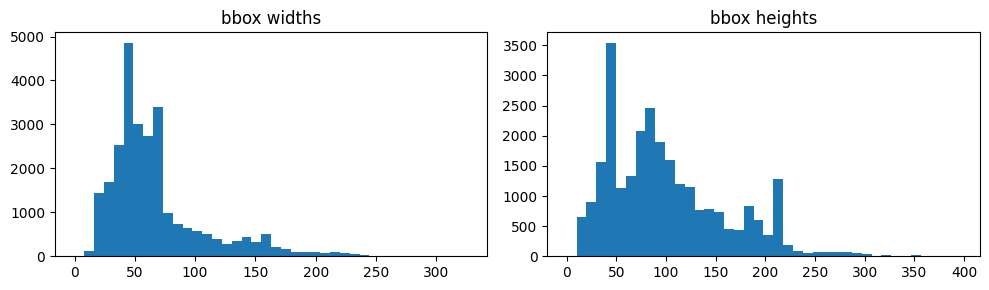

In [ ]:
# Optional: distribution of bbox widths and heights across training sequences.
_all_w, _all_h = [], []
for name in train_sequences:
    _, gts = load_sequence_with_gt(DATA_ROOT / name)
    _all_w.extend(gts[:, 2].tolist())
    _all_h.extend(gts[:, 3].tolist())

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(_all_w, bins=40); axes[0].set_title("bbox widths")
axes[1].hist(_all_h, bins=40); axes[1].set_title("bbox heights")
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "part1_bbox_size_hist.png", dpi=120)
plt.show()


## (Optional) Target Motion Visualization

For one selected sequence, plot the target center coordinates over time.

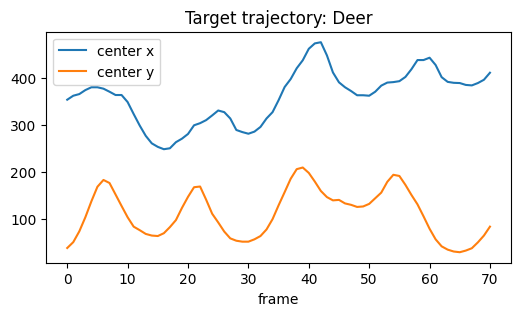

In [ ]:
# Optional: target center trajectory over time for one training sequence.
if train_sequences:
    _seq = train_sequences[0]
    _, _gts = load_sequence_with_gt(DATA_ROOT / _seq)
    _cx = _gts[:, 0] + _gts[:, 2] / 2
    _cy = _gts[:, 1] + _gts[:, 3] / 2
    plt.figure(figsize=(6, 3))
    plt.plot(_cx, label="center x")
    plt.plot(_cy, label="center y")
    plt.title(f"Target trajectory: {_seq}")
    plt.xlabel("frame"); plt.legend()
    plt.savefig(OUTPUT_ROOT / "part1_trajectory.png", dpi=120)
    plt.show()


# PART 2 — Search-Region Sample Generation

In single-object tracking, the target is initialized in the first frame. For later frames, the tracker searches around the previous target location.

In this assignment, you will train a model that receives a local search crop and predicts the target box inside that crop.

For a pair of consecutive frames:

```text
Frame t-1 bbox -> used to define the search region in frame t
Frame t bbox   -> target label inside the search region
```

## 2.1 Crop Metadata

`CropInfo` stores the information needed to convert between:

- full-frame coordinates,
- crop-local normalized coordinates.

In [ ]:
@dataclass
class CropInfo:
    """
    Metadata for mapping between crop coordinates and full-frame coordinates.

    x1, y1:
        Top-left location of the crop in the original image coordinate system.
        These may be negative if padding is used.

    crop_size:
        Side length of the square crop in original image pixels.

    output_size:
        Side length after resizing the crop for the CNN.
    """
    x1: float
    y1: float
    crop_size: float
    output_size: int

## 2.2 Bounding-Box Helper Functions

Implement simple helper functions for bounding-box center computation and clipping predictions to image boundaries.

In [ ]:
def bbox_center(bbox: np.ndarray) -> Tuple[float, float]:
    """Compute the center of a bbox in (x, y, w, h) format."""
    x, y, w, h = bbox
    return float(x + w / 2), float(y + h / 2)


def clip_bbox_to_image(bbox: np.ndarray, image_shape: Tuple[int, int, int]) -> np.ndarray:
    """Clip a bbox to image boundaries and keep width/height positive."""
    H, W = image_shape[:2]
    x, y, w, h = bbox
    x2 = x + w
    y2 = y + h
    # Clamp each corner into [0, W] / [0, H]. A box edge can legitimately
    # sit on the right/bottom of the image, so we use W/H (not W-1/H-1).
    x  = max(0.0, min(float(x),  float(W)))
    y  = max(0.0, min(float(y),  float(H)))
    x2 = max(0.0, min(float(x2), float(W)))
    y2 = max(0.0, min(float(y2), float(H)))
    # Recompute width/height; ensure they stay >= 1.
    w = max(1.0, x2 - x)
    h = max(1.0, y2 - y)
    return np.array([x, y, w, h], dtype=np.float32)


## 2.3 Search-Region Crop

Use a square search region centered around the previous bounding box.

The recommended crop size is:

```text
crop_size = scale × max(previous_width, previous_height)
```

A reasonable default value is `scale = 2.5`.

If the crop goes outside the image, handle the boundary carefully. You may use padding or clipping, but your coordinate conversion must remain correct.

In [ ]:
def crop_search_region(
    image: np.ndarray,
    previous_bbox: np.ndarray,
    scale: float = 2.5,
    output_size: int = IMAGE_SIZE,
    pad_value: Tuple[int, int, int] = (128, 128, 128),
) -> Tuple[np.ndarray, CropInfo]:
    """
    Crop a square search region around the previous bounding box.

    Returns:
        crop_resized: RGB crop resized to output_size x output_size
        crop_info: metadata for coordinate conversion. Stores the
            ROUNDED pixel-space origin and side length that were
            actually used to slice the image, so that the inverse
            mapping is exact (no sub-pixel drift between the image
            content the model saw and the supervised target coords).
    """
    H, W = image.shape[:2]
    cx, cy = bbox_center(previous_bbox)

    crop_size_f = float(scale * max(previous_bbox[2], previous_bbox[3]))
    crop_size_f = max(crop_size_f, 8.0)   # never let it collapse to zero

    # Round to integer pixels so the stored geometry matches the slice.
    crop_size_px = int(round(crop_size_f))
    half = crop_size_px / 2.0

    # Square crop corners in the ORIGINAL image coordinate system.
    x1f = cx - half
    y1f = cy - half
    x1 = int(round(x1f))
    y1 = int(round(y1f))
    x2 = x1 + crop_size_px
    y2 = y1 + crop_size_px

    # Compute padding if the crop goes outside the image boundaries.
    pad_left   = max(0, -x1)
    pad_top    = max(0, -y1)
    pad_right  = max(0, x2 - W)
    pad_bottom = max(0, y2 - H)

    if pad_left or pad_top or pad_right or pad_bottom:
        padded = cv2.copyMakeBorder(
            image,
            pad_top, pad_bottom, pad_left, pad_right,
            borderType=cv2.BORDER_CONSTANT,
            value=pad_value,
        )
    else:
        padded = image

    # Adjust crop coordinates to the padded image, then slice.
    px1 = x1 + pad_left
    py1 = y1 + pad_top
    px2 = px1 + crop_size_px
    py2 = py1 + crop_size_px
    crop = padded[py1:py2, px1:px2]

    # Resize the crop to the output size.
    crop_resized = cv2.resize(crop, (output_size, output_size), interpolation=cv2.INTER_LINEAR)

    # CropInfo carries the integer-pixel geometry actually used, so that
    # bbox_to_crop_coordinates / crop_to_frame_coordinates are exact inverses.
    crop_info = CropInfo(
        x1=float(x1),
        y1=float(y1),
        crop_size=float(crop_size_px),
        output_size=output_size,
    )

    return crop_resized, crop_info


## 2.4 Coordinate Conversion

The model predicts boxes inside the crop, but the final tracking output must be in full-frame coordinates.

You need two conversions:

1. Full-frame bbox → crop-local normalized bbox  
2. Crop-local normalized bbox → full-frame bbox

In [ ]:
def bbox_to_crop_coordinates(bbox: np.ndarray, crop_info: CropInfo) -> np.ndarray:
    """
    Convert a full-frame bbox into normalized crop coordinates.

    Shift by the crop's top-left, then divide by the crop side length.

    Returns:
        normalized_bbox: (x, y, w, h), usually in [0, 1]
    """
    x, y, w, h = bbox
    nx = (x - crop_info.x1) / crop_info.crop_size
    ny = (y - crop_info.y1) / crop_info.crop_size
    nw = w / crop_info.crop_size
    nh = h / crop_info.crop_size
    return np.array([nx, ny, nw, nh], dtype=np.float32)


def crop_to_frame_coordinates(normalized_bbox: np.ndarray, crop_info: CropInfo) -> np.ndarray:
    """
    Convert a normalized crop-local bbox back to full-frame coordinates.

    Exact inverse of bbox_to_crop_coordinates: multiply by the crop side
    length, then add back the crop's top-left.
    """
    nx, ny, nw, nh = normalized_bbox
    x = nx * crop_info.crop_size + crop_info.x1
    y = ny * crop_info.crop_size + crop_info.y1
    w = nw * crop_info.crop_size
    h = nh * crop_info.crop_size
    return np.array([x, y, w, h], dtype=np.float32)


## 2.5 Search-Region Visualization

Visualize several generated search-region samples.

For each sample, draw the current target box inside the search crop.

This is one of the most important sanity checks in the assignment.

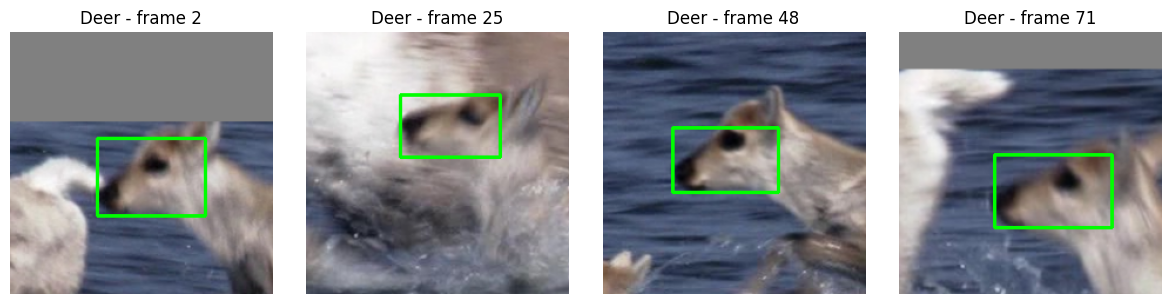

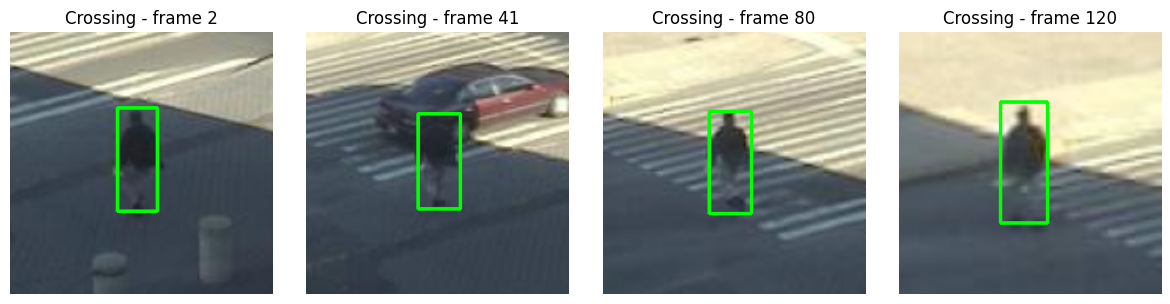

In [ ]:
# Sanity check: build search crops and draw the CURRENT frame's GT box inside
# the crop. If the green box lands tightly on the object inside every crop,
# our cropping + coordinate conversion are correct.
def visualize_search_samples(seq_name: str, num: int = 4):
    frames, gts = load_sequence_with_gt(DATA_ROOT / seq_name)
    # Pick frames spread across the sequence (start from frame 1, since we need
    # a "previous" frame to define the search region).
    idxs = np.linspace(1, len(frames) - 1, num).astype(int)

    fig, axes = plt.subplots(1, num, figsize=(3 * num, 3))
    if num == 1:
        axes = [axes]
    for ax, t in zip(axes, idxs):
        img = read_image_rgb(frames[t])
        # Use the PREVIOUS frame's box to define the crop in the current frame.
        crop, info = crop_search_region(img, gts[t - 1],
                                        scale=SEARCH_SCALE, output_size=IMAGE_SIZE)
        # Convert the CURRENT frame's GT box into the crop's normalized coords,
        # then scale to 224x224 pixels to draw it.
        norm = bbox_to_crop_coordinates(gts[t], info)
        px_box = norm * IMAGE_SIZE
        crop_drawn = draw_bbox(crop, px_box, color=(0, 255, 0), thickness=2)
        ax.imshow(crop_drawn)
        ax.set_title(f"{seq_name} - frame {t + 1}")
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / f"part2_search_samples_{seq_name}.png", dpi=120)
    plt.show()

# Visualize samples from two training sequences.
for s in train_sequences[:2]:
    visualize_search_samples(s, num=4)


# PART 3 — CNN-Based Bounding-Box Regression Model

In this part, you will train a CNN to predict the target bounding box inside a search crop.

The model input is:

```text
224 × 224 RGB search crop
```

The model output is:

```text
x, y, width, height
```

The output must be crop-local and normalized to `[0, 1]`.

Do not train the model with full-frame coordinates.

## 3.1 Model Architecture Overview

Recommended architecture:

```text
Search Region Crop
        ↓
Preprocessing
        ↓
CNN Backbone
        ↓
Regression Head
        ↓
Normalized Bounding Box [x, y, w, h]
        ↓
Convert to full-frame coordinates during tracking
```

You may use an ImageNet-pretrained ResNet18 backbone. Replace its final classification layer with a regression layer that outputs four values.

## 3.2 PyTorch Dataset

Implement a PyTorch dataset that generates search-region samples from training sequences.

Each sample should contain:

```text
input: search crop from current frame
target: current target bbox in crop-local normalized coordinates
```

Use validation sequences similarly for crop-level validation.

In [ ]:
class SearchRegionDataset(Dataset):
    """
    Dataset that generates search-region samples from full-GT sequences.

    Each sample:
        input: current frame search crop around a *previous* GT bbox
        target: current GT bbox in normalized crop coordinates

    `gaps` controls frame-pair distances: a sample is built as
    (frames[t], gts[t - k], gts[t]) for each k in `gaps`. The default
    (1,) reproduces the original consecutive-pair behavior; training
    uses (1, 2, 3, 5) to teach larger motion and 4x the dataset.
    """

    def __init__(
        self,
        data_root: Path,
        sequence_names: List[str],
        image_size: int = IMAGE_SIZE,
        search_scale: float = SEARCH_SCALE,
        augment: bool = False,
        gaps: Tuple[int, ...] = (1,),
    ):
        self.data_root = Path(data_root)
        self.sequence_names = sequence_names
        self.image_size = image_size
        self.search_scale = search_scale
        self.augment = augment
        self.gaps = tuple(gaps)

        # Build a flat list of (current_frame_path, prev_bbox, cur_bbox).
        self.samples = []
        for name in sequence_names:
            frames, gts = load_sequence_with_gt(self.data_root / name)
            for t in range(1, len(frames)):
                for k in self.gaps:
                    if t - k < 0:
                        continue
                    prev = gts[t - k]
                    # Skip degenerate previous boxes (zero/near-zero size).
                    if prev[2] <= 1 or prev[3] <= 1:
                        continue
                    self.samples.append((frames[t], prev.copy(), gts[t].copy()))

        # ImageNet normalization, applied to the crop tensor.
        self.normalize = transforms.Normalize(
            mean=IMAGENET_MEAN.tolist(),
            std=IMAGENET_STD.tolist(),
        )
        # Photometric augmentation, applied to the crop tensor in [0, 1]
        # BEFORE normalize. Skip hue (slow, rarely helps for tracking).
        self.color_jitter = transforms.ColorJitter(
            brightness=0.3, contrast=0.3, saturation=0.3
        )

    def __len__(self):
        return len(self.samples)

    def _jitter_prev_bbox(self, bbox: np.ndarray) -> np.ndarray:
        """Shift + scale the previous box to mimic tracker noise.

        Phase 1: shift +-0.20 * max(w, h), scale in [0.75, 1.25].
        Larger than the original +-0.10 / [0.9, 1.1] to close the
        train/test distribution gap.
        """
        x, y, w, h = bbox
        shift = 0.20 * max(w, h)
        sx = np.random.uniform(-shift, shift)
        sy = np.random.uniform(-shift, shift)
        s = np.random.uniform(0.75, 1.25)
        nw = max(2.0, w * s)
        nh = max(2.0, h * s)
        cx = x + w / 2 + sx
        cy = y + h / 2 + sy
        return np.array([cx - nw / 2, cy - nh / 2, nw, nh], dtype=np.float32)

    @staticmethod
    def _flip_crop_and_target(crop: np.ndarray, target: np.ndarray):
        """Horizontal flip of the crop and the normalized target.

        Crop is HWC; flipping along axis=1 mirrors left/right.
        For a target (nx, ny, nw, nh) in normalized crop coords, the
        flipped x is `1 - nx - nw`; y/w/h are unchanged.
        """
        crop_f = np.ascontiguousarray(crop[:, ::-1, :])
        nx, ny, nw, nh = target
        target_f = np.array([1.0 - nx - nw, ny, nw, nh], dtype=np.float32)
        return crop_f, target_f

    def __getitem__(self, idx):
        frame_path, prev_bbox, cur_bbox = self.samples[idx]
        img = read_image_rgb(frame_path)

        if self.augment:
            prev_bbox = self._jitter_prev_bbox(prev_bbox)

        # 1. Build the search crop around the (jittered) previous box.
        crop, info = crop_search_region(img, prev_bbox,
                                        scale=self.search_scale,
                                        output_size=self.image_size)
        # 2. Target = current box in this crop's normalized coords.
        target = bbox_to_crop_coordinates(cur_bbox, info)
        target = np.clip(target, -0.5, 1.5).astype(np.float32)  # guard outliers

        # 3. Horizontal flip (both crop and target) with p=0.5.
        if self.augment and np.random.rand() < 0.5:
            crop, target = self._flip_crop_and_target(crop, target)

        # 4. HWC uint8 -> CHW float in [0, 1]; color jitter in [0, 1];
        #    then ImageNet normalize.
        crop_t = torch.from_numpy(crop).permute(2, 0, 1).float() / 255.0
        if self.augment:
            crop_t = self.color_jitter(crop_t)
        crop_t = self.normalize(crop_t)

        return crop_t, torch.from_numpy(target)


## 3.3 DataLoaders

Create train and validation DataLoaders.

Training samples should come only from the training split. Validation samples should come only from the validation split.

In [ ]:
def _seed_worker(worker_id: int):
    """Re-seed numpy and python random per DataLoader worker."""
    seed = (torch.initial_seed() + worker_id) % (2**32)
    np.random.seed(seed)
    random.seed(seed)


def create_dataloaders(
    data_root: Path,
    train_sequences: List[str],
    val_sequences: List[str],
    batch_size: int = BATCH_SIZE,
    image_size: int = IMAGE_SIZE,
    search_scale: float = SEARCH_SCALE,
    train_gaps: Tuple[int, ...] = (1, 2),
):
    """Create train and validation datasets + dataloaders.

    Train: skip-frame sampling (gaps (1,2,3,5)) + jitter + color jitter + flip.
    Val:   consecutive pairs only (gap 1), no augmentation — so val IoU
           stays comparable across experiments.
    """
    train_ds = SearchRegionDataset(data_root, train_sequences,
                                   image_size=image_size,
                                   search_scale=search_scale,
                                   augment=True,
                                   gaps=train_gaps)
    val_ds = SearchRegionDataset(data_root, val_sequences,
                                 image_size=image_size,
                                 search_scale=search_scale,
                                 augment=False,
                                 gaps=(1,))

    g = torch.Generator()
    g.manual_seed(SEED)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size,
        shuffle=True, num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        worker_init_fn=_seed_worker, generator=g,
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size,
        shuffle=False, num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        worker_init_fn=_seed_worker,
    )
    return train_ds, val_ds, train_loader, val_loader


train_dataset, val_dataset, train_loader, val_loader = create_dataloaders(
    DATA_ROOT, train_sequences, val_sequences,
    batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, search_scale=SEARCH_SCALE,
)
print(f"train samples: {len(train_dataset)} | val samples: {len(val_dataset)}")


train samples: 105919 | val samples: 5041


## 3.4 Model Definition

Define your CNN-based bounding-box regressor.

Recommended design:
- pretrained ResNet18 backbone,
- final regression layer with 4 outputs,
- output activation to keep predictions in `[0, 1]`.

In [ ]:
class TrackingRegressor(nn.Module):
    """ResNet18 backbone + small regression head -> normalized (x, y, w, h)."""

    def __init__(self, pretrained: bool = True):
        super().__init__()
        # 1. Load ResNet18, optionally with ImageNet-pretrained weights.
        if pretrained:
            weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1
        else:
            weights = None
        backbone = torchvision.models.resnet18(weights=weights)

        # 2. Replace the final classification layer with a regression head.
        feat_dim = backbone.fc.in_features   # 512 for ResNet18
        backbone.fc = nn.Identity()          # keep features, drop the classifier
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(256, 4),               # outputs x, y, w, h
        )

    def forward(self, x):
        feat = self.backbone(x)
        out = self.head(feat)
        return torch.sigmoid(out)            # keep predictions in [0, 1]


def create_model() -> nn.Module:
    """Create the model and move it to DEVICE."""
    return TrackingRegressor(pretrained=True).to(DEVICE)


model = create_model()
print(model.head)


Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.1, inplace=False)
  (3): Linear(in_features=256, out_features=4, bias=True)
)


## 3.5 IoU for Crop-Level Validation

Implement IoU calculation for boxes in `(x, y, w, h)` format.

This function will be used both for crop-level validation and sequence-level evaluation.

In [ ]:
def compute_iou_np(box_a: np.ndarray, box_b: np.ndarray) -> float:
    """IoU between two boxes in (x, y, w, h) format."""
    ax1, ay1, aw, ah = box_a
    bx1, by1, bw, bh = box_b
    ax2, ay2 = ax1 + aw, ay1 + ah
    bx2, by2 = bx1 + bw, by1 + bh

    # Intersection rectangle.
    ix1 = max(ax1, bx1); iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2); iy2 = min(ay2, by2)
    iw = max(0.0, ix2 - ix1); ih = max(0.0, iy2 - iy1)
    inter = iw * ih

    union = max(0.0, aw) * max(0.0, ah) + max(0.0, bw) * max(0.0, bh) - inter
    if union <= 0:
        return 0.0
    return float(inter / union)


def mean_iou_batch(preds: torch.Tensor, targets: torch.Tensor) -> float:
    """Mean IoU over a batch of predicted/target boxes (tensors on any device)."""
    p = preds.detach().cpu().numpy()
    t = targets.detach().cpu().numpy()
    ious = [compute_iou_np(p[i], t[i]) for i in range(len(p))]
    return float(np.mean(ious)) if ious else 0.0


## 3.6 Training and Validation Loops

Use a regression loss such as Smooth L1 loss.

During training, update model parameters.  
During validation, do not update model parameters.

Record:
- training loss,
- validation loss,
- validation crop-level mean IoU.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """One pass over the training data; returns mean training loss."""
    model.train()
    total_loss, n = 0.0, 0
    for crops, targets in loader:
        crops = crops.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        preds = model(crops)
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = crops.size(0)
        total_loss += loss.item() * bs
        n += bs
    return total_loss / max(1, n)


@torch.no_grad()
def validate_model(model, loader, criterion, device):
    """Evaluate without updating weights; returns loss + crop-level mean IoU."""
    model.eval()
    total_loss, n = 0.0, 0
    iou_sum = 0.0
    for crops, targets in loader:
        crops = crops.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        preds = model(crops)
        loss = criterion(preds, targets)

        bs = crops.size(0)
        total_loss += loss.item() * bs
        iou_sum += mean_iou_batch(preds, targets) * bs
        n += bs
    return {
        "val_loss": total_loss / max(1, n),
        "val_iou": iou_sum / max(1, n),
    }


def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs: int = NUM_EPOCHS,
    lr: float = LEARNING_RATE,
    device: torch.device = DEVICE,
):
    """Full training loop. Saves the best model (by val IoU) to checkpoint/.

    Optimizer: Adam (as suggested by the assignment).
    """
    criterion = nn.SmoothL1Loss(beta=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {"train_loss": [], "val_loss": [], "val_iou": []}
    best_iou = -1.0
    best_epoch = -1
    best_state = None

    for epoch in range(1, num_epochs + 1):
        tr = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val = validate_model(model, val_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(tr)
        history["val_loss"].append(val["val_loss"])
        history["val_iou"].append(val["val_iou"])
        print(f"epoch {epoch:02d} | train {tr:.4f} | "
              f"val {val['val_loss']:.4f} | val IoU {val['val_iou']:.4f}")

        # Keep the best weights by validation crop-level IoU.
        if val["val_iou"] > best_iou:
            best_iou = val["val_iou"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_state, CHECKPOINT_ROOT / "best_model.pt")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"best val IoU = {best_iou:.4f} at epoch {best_epoch}")
    return history


## 3.7 Train the Model

Train your model using the training split and monitor performance on the validation split.

Save the best model according to validation performance.

In [ ]:
history = train_model(model, train_loader, val_loader,
                      num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, device=DEVICE)
print(f"best val crop-level IoU: {max(history['val_iou']):.4f}")


epoch 01 | train 0.0052 | val 0.0307 | val IoU 0.4913
epoch 02 | train 0.0025 | val 0.0368 | val IoU 0.4346
epoch 03 | train 0.0020 | val 0.0371 | val IoU 0.4630
epoch 04 | train 0.0018 | val 0.0370 | val IoU 0.4702


## 3.8 Training Curves

Plot:
- training loss,
- validation loss,
- validation crop-level mean IoU.

Briefly comment on whether the model appears to learn.

In [ ]:
# Plot training/validation loss and validation crop-level IoU.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("Smooth L1 loss")
axes[0].set_title("Loss curves"); axes[0].legend()

axes[1].plot(history["val_iou"])
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("crop-level mean IoU")
axes[1].set_title("Validation IoU")

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "part3_training_curves.png", dpi=120)
plt.show()


## 3.9 Visualize Crop-Level Validation Predictions

Visualize at least five validation crop predictions.

Draw:
- ground-truth box,
- predicted box.

This helps check whether the model learned meaningful localization.

In [ ]:
def denormalize_tensor_image(tensor_img: torch.Tensor) -> np.ndarray:
    """Undo ImageNet normalization -> uint8 RGB image for display."""
    img = tensor_img.detach().cpu().numpy().transpose(1, 2, 0)   # CHW -> HWC
    img = img * IMAGENET_STD + IMAGENET_MEAN
    img = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    return img


@torch.no_grad()
def visualize_validation_predictions(model, dataset, num_samples: int = 5):
    """Draw GT (green) and predicted (red) boxes on validation crops."""
    model.eval()
    n = min(num_samples, len(dataset))
    idxs = np.linspace(0, len(dataset) - 1, n).astype(int)

    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]
    for ax, i in zip(axes, idxs):
        crop_t, target = dataset[int(i)]
        pred = model(crop_t.unsqueeze(0).to(DEVICE))[0].cpu().numpy()

        img = denormalize_tensor_image(crop_t)
        gt_px = target.numpy() * IMAGE_SIZE     # normalized -> 224px pixels
        pr_px = pred * IMAGE_SIZE

        img = draw_bbox(img, gt_px, color=(0, 255, 0), thickness=2, label="GT")
        img = draw_bbox(img, pr_px, color=(255, 0, 0), thickness=2, label="Pred")
        ax.imshow(img); ax.axis("off"); ax.set_title(f"val #{i}")
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / "part3_val_predictions.png", dpi=120)
    plt.show()


visualize_validation_predictions(model, val_dataset, num_samples=5)


# PART 4 — Single-Object Tracking on Validation and Test Sequences

After training the model, use it as a tracker.

For validation sequences:
- use the first line of `groundtruth_rect.txt` as initialization,
- predict all later frames,
- evaluate after tracking.

For test sequences:
- use `init_rect.txt` as initialization,
- predict all later frames,
- save CSV files,
- do not evaluate locally.

## 4.1 Evaluation-Time Preprocessing

Use the same preprocessing during tracking that you used during training.

Do not apply random augmentation during validation or test tracking.

In [ ]:
# (Removed unused `eval_transform`: tracking-time preprocessing happens
# in `predict_bbox_in_crop` below, using the same IMAGENET_MEAN/STD as the
# training Dataset so train/test inputs match exactly.)


## 4.2 Predict a Box Inside One Crop

This helper runs the model on one search crop and returns a normalized crop-local bounding box.

In [ ]:
@torch.no_grad()
def predict_bbox_in_crop(model, crop_rgb: np.ndarray, device: torch.device = DEVICE) -> np.ndarray:
    """Run the model on a single 224x224 RGB crop, return normalized (x, y, w, h).

    `crop_search_region` already returns an `output_size x output_size` crop,
    so no resize is needed here. We mirror the training-time preprocessing
    (HWC uint8 -> CHW float in [0,1] -> ImageNet normalize) exactly.
    """
    model.eval()
    assert crop_rgb.shape[0] == IMAGE_SIZE and crop_rgb.shape[1] == IMAGE_SIZE, \
        f"expected {IMAGE_SIZE}x{IMAGE_SIZE} crop, got {crop_rgb.shape[:2]}"

    t = torch.from_numpy(crop_rgb).permute(2, 0, 1).float() / 255.0
    mean = torch.from_numpy(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.from_numpy(IMAGENET_STD).view(3, 1, 1)
    t = (t - mean) / std

    pred = model(t.unsqueeze(0).to(device))[0].cpu().numpy()
    return pred.astype(np.float32)


## 4.3 Tracking Loop

Implement the full single-object tracking loop.

The function should receive only:

```text
model
frame paths
initial bbox
```

It must not receive the full ground-truth array.

In [ ]:
@torch.no_grad()
def track_sequence(
    model,
    frame_paths: List[Path],
    initial_bbox: np.ndarray,
    device: torch.device = DEVICE,
    scale: float = SEARCH_SCALE,
    image_size: int = IMAGE_SIZE,
    min_size_ratio: float = 0.3,
    max_size_ratio: float = 3.0,
) -> np.ndarray:
    """
    Track the target object through a sequence.

    Returns predictions: (N, 4) array of full-frame (x, y, w, h) boxes.

    Important: only frame 1 uses the given initial_bbox. Every later frame
    is driven by the model's OWN previous prediction (no ground truth).

    Failure recovery: a single-frame regressor can predict a degenerate
    (tiny or huge) box that then collapses the next search crop, after
    which the tracker can never recover. If the predicted width or height
    falls outside [min_size_ratio, max_size_ratio] x the previous size,
    we keep the previous box's size (and just move its center to the
    prediction's center).
    """
    model.eval()
    N = len(frame_paths)
    preds = np.zeros((N, 4), dtype=np.float32)
    preds[0] = np.asarray(initial_bbox, dtype=np.float32)

    cur = preds[0].copy()
    for t in range(1, N):
        img = read_image_rgb(frame_paths[t])
        # 1. Search crop around the previous prediction.
        crop, info = crop_search_region(img, cur, scale=scale, output_size=image_size)
        # 2. Predict the box inside the crop (normalized).
        norm_pred = predict_bbox_in_crop(model, crop, device=device)
        # 3. Convert back to full-frame coordinates.
        frame_box = crop_to_frame_coordinates(norm_pred, info)

        # 4. Failure recovery: reject pathological size changes.
        pw, ph = cur[2], cur[3]
        nw, nh = frame_box[2], frame_box[3]
        size_ok = (
            min_size_ratio * pw <= nw <= max_size_ratio * pw and
            min_size_ratio * ph <= nh <= max_size_ratio * ph
        )
        if not size_ok:
            # Keep previous size, take new center from the prediction.
            ncx = frame_box[0] + nw / 2
            ncy = frame_box[1] + nh / 2
            frame_box = np.array(
                [ncx - pw / 2, ncy - ph / 2, pw, ph], dtype=np.float32
            )

        # 5. Keep it inside the image.
        frame_box = clip_bbox_to_image(frame_box, img.shape)
        # 6. Save, and use it as the "previous" box for the next frame.
        preds[t] = frame_box
        cur = frame_box
    return preds


## 4.4 Save Prediction CSV Files

Save predictions in the required format.

The saved coordinates must be full-frame pixel coordinates.

In [ ]:
def save_predictions_csv(predictions: np.ndarray, output_path: Path):
    """
    Save predictions as:
        frame,x,y,w,h
        1,...
        2,...

    Coordinates are full-frame pixel coordinates (not normalized crop coords).
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["frame", "x", "y", "w", "h"])
        for i, b in enumerate(predictions, start=1):
            writer.writerow([i, f"{b[0]:.3f}", f"{b[1]:.3f}",
                             f"{b[2]:.3f}", f"{b[3]:.3f}"])


## 4.5 Run Tracking on Validation Sequences

Use the first validation ground-truth box for initialization.

Save validation predictions under:

```text
outputs/validation/
```

In [ ]:
def run_tracking_on_validation_sequences(
    model,
    data_root: Path,
    sequence_names: List[str],
    output_root: Path,
    device: torch.device = DEVICE,
    scale: float = SEARCH_SCALE,
) -> Dict[str, np.ndarray]:
    """Track each validation sequence (init from GT frame 1) and save CSVs."""
    out_dir = Path(output_root) / "validation"
    out_dir.mkdir(parents=True, exist_ok=True)
    results = {}
    for name in sequence_names:
        frames, gts = load_sequence_with_gt(Path(data_root) / name)
        preds = track_sequence(model, frames, gts[0], device=device, scale=scale)
        save_predictions_csv(preds, out_dir / f"{name}_predictions.csv")
        results[name] = preds
        print(f"  [val] {name}: {len(frames)} frames tracked")
    return results


## 4.6 Run Tracking on Test Sequences

Use `init_rect.txt` for initialization.

Save test predictions under:

```text
outputs/test/
```

These files will be submitted for evaluation.

In [ ]:
def run_tracking_on_test_sequences(
    model,
    data_root: Path,
    sequence_names: List[str],
    output_root: Path,
    device: torch.device = DEVICE,
    scale: float = SEARCH_SCALE,
) -> Dict[str, np.ndarray]:
    """Track each test sequence (init from init_rect.txt) and save CSVs."""
    out_dir = Path(output_root) / "test"
    out_dir.mkdir(parents=True, exist_ok=True)
    results = {}
    for name in sequence_names:
        frames, init_box = load_test_sequence(Path(data_root) / name)
        preds = track_sequence(model, frames, init_box, device=device, scale=scale)
        save_predictions_csv(preds, out_dir / f"{name}_predictions.csv")
        results[name] = preds
        print(f"  [test] {name}: {len(frames)} frames tracked")
    return results


## 4.7 Execute Tracking

Run tracking on validation and test sequences.

Make sure the generated test CSV files are complete and correctly formatted.

In [ ]:
print("Tracking validation sequences...")
val_predictions = run_tracking_on_validation_sequences(
    model, DATA_ROOT, val_sequences, OUTPUT_ROOT, device=DEVICE, scale=SEARCH_SCALE,
)

print("\nTracking test sequences...")
test_predictions = run_tracking_on_test_sequences(
    model, DATA_ROOT, test_sequences, OUTPUT_ROOT, device=DEVICE, scale=SEARCH_SCALE,
)
print("\nDone. CSVs saved under outputs/validation/ and outputs/test/.")


# Required Test Output Format

For each test sequence, save one CSV file:

```text
outputs/test/<sequence_name>_predictions.csv
```

Each CSV file must contain:

```text
frame,x,y,w,h
```

Rules:

1. Number of rows must equal the number of frames.
2. Frame numbering must start from 1.
3. The first-frame prediction should be the initialization box from `init_rect.txt`.
4. Coordinates must be full-frame pixel coordinates.
5. Do not save normalized crop coordinates.
6. Bounding boxes must be in `(x, y, width, height)` format.

# PART 5 — Validation Evaluation and Analysis

Evaluate your tracker on validation sequences using the provided validation ground truth.

Do not evaluate test sequences. Test ground truth is hidden and will be evaluated by the instructors.

Required validation metrics:

1. Mean IoU  
2. Success Rate @ IoU ≥ 0.5  
3. Average Center Error  
4. Failure Count, where failure means IoU < 0.1

## 5.1 Metric Functions

Implement IoU, center error, and sequence-level evaluation.

In [ ]:
def compute_iou(box_a: np.ndarray, box_b: np.ndarray) -> float:
    """IoU between two boxes in (x, y, w, h) format. Wraps compute_iou_np."""
    return compute_iou_np(box_a, box_b)


def compute_center_error(box_a: np.ndarray, box_b: np.ndarray) -> float:
    """Euclidean distance between the centers of two (x, y, w, h) boxes."""
    ax, ay, aw, ah = box_a
    bx, by, bw, bh = box_b
    acx, acy = ax + aw / 2.0, ay + ah / 2.0
    bcx, bcy = bx + bw / 2.0, by + bh / 2.0
    return float(np.hypot(acx - bcx, acy - bcy))


def evaluate_sequence(
    predictions: np.ndarray,
    ground_truth: np.ndarray,
    success_iou_threshold: float = 0.5,
    failure_iou_threshold: float = 0.1,
) -> Dict[str, float]:
    """
    Evaluate one validation tracking sequence.

    Args:
        predictions:  (N, 4) full-frame (x, y, w, h) boxes from track_sequence.
        ground_truth: (N, 4) full-frame GT boxes.
        success_iou_threshold: IoU above which a frame counts as a "success".
        failure_iou_threshold: IoU below which a frame counts as a "failure".

    Returns dict with mean_iou, success_rate_0.5, avg_center_error,
    failure_count, num_frames.
    """
    predictions = np.asarray(predictions, dtype=np.float32)
    ground_truth = np.asarray(ground_truth, dtype=np.float32)
    if len(predictions) != len(ground_truth):
        raise ValueError(
            f"length mismatch: {len(predictions)} preds vs {len(ground_truth)} gts"
        )

    n = len(predictions)
    ious = np.array([compute_iou(predictions[i], ground_truth[i]) for i in range(n)],
                    dtype=np.float32)
    cerrs = np.array([compute_center_error(predictions[i], ground_truth[i]) for i in range(n)],
                     dtype=np.float32)

    return {
        "mean_iou":          float(ious.mean()) if n else 0.0,
        "success_rate_0.5":  float((ious >= success_iou_threshold).mean()) if n else 0.0,
        "avg_center_error":  float(cerrs.mean()) if n else 0.0,
        "failure_count":     int((ious < failure_iou_threshold).sum()),
        "num_frames":        int(n),
    }


## 5.2 Evaluate All Validation Sequences

Create a result table with one row per validation sequence and one final average row.

In [ ]:
def evaluate_validation_sequences(
    predictions_by_sequence: Dict[str, np.ndarray],
    data_root: Path,
) -> pd.DataFrame:
    """Evaluate every validation sequence; return a per-sequence + average table.

    The returned DataFrame has one row per sequence plus a final "MEAN" row
    (frame-weighted mean IoU / success rate; simple mean of center error).
    """
    rows = []
    total_frames = 0
    iou_weighted = 0.0
    succ_weighted = 0.0
    cerr_sum = 0.0
    fail_total = 0

    for name in sorted(predictions_by_sequence.keys()):
        preds = predictions_by_sequence[name]
        _, gts = load_sequence_with_gt(Path(data_root) / name)
        metrics = evaluate_sequence(preds, gts)
        rows.append({"sequence": name, **metrics})

        n = metrics["num_frames"]
        total_frames += n
        iou_weighted  += metrics["mean_iou"] * n
        succ_weighted += metrics["success_rate_0.5"] * n
        cerr_sum      += metrics["avg_center_error"] * n
        fail_total    += metrics["failure_count"]

    df = pd.DataFrame(rows)

    if total_frames > 0:
        df.loc[len(df)] = {
            "sequence":          "MEAN",
            "mean_iou":          iou_weighted / total_frames,
            "success_rate_0.5":  succ_weighted / total_frames,
            "avg_center_error":  cerr_sum / total_frames,
            "failure_count":     fail_total,
            "num_frames":        total_frames,
        }
    return df


# Run evaluation on the val_predictions produced by Part 4.
val_metrics_df = evaluate_validation_sequences(val_predictions, DATA_ROOT)
print(val_metrics_df.to_string(index=False))
val_metrics_df.to_csv(OUTPUT_ROOT / "validation_metrics.csv", index=False)


## 5.3 Visualize Validation Tracking Results

Visualize tracking results for at least three validation sequences.

For each selected sequence, show:
- an early frame,
- a middle frame,
- a late frame.

Draw both the ground-truth and predicted bounding boxes.

In [ ]:
def visualize_validation_tracking_result(
    sequence_name: str,
    predictions: np.ndarray,
    data_root: Path,
    frame_indices: Optional[List[int]] = None,
    num_frames: int = 5,
    save: bool = True,
):
    """Draw GT (green) and prediction (red) on selected frames of one sequence.

    If `frame_indices` is None, picks `num_frames` evenly spaced frames.
    """
    frames, gts = load_sequence_with_gt(Path(data_root) / sequence_name)
    N = len(frames)

    if frame_indices is None:
        frame_indices = np.linspace(0, N - 1, num_frames).astype(int).tolist()

    n = len(frame_indices)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]

    for ax, t in zip(axes, frame_indices):
        img = read_image_rgb(frames[int(t)])
        img = draw_bbox(img, gts[int(t)],         color=(0, 255, 0), thickness=2, label="GT")
        img = draw_bbox(img, predictions[int(t)], color=(255, 0, 0), thickness=2, label="Pred")
        iou = compute_iou(predictions[int(t)], gts[int(t)])
        ax.imshow(img)
        ax.set_title(f"{sequence_name} f{int(t)+1} IoU={iou:.2f}")
        ax.axis("off")

    plt.tight_layout()
    if save:
        plt.savefig(OUTPUT_ROOT / f"part5_track_{sequence_name}.png", dpi=120)
    plt.show()


# Visualize tracking on at least three validation sequences.
_to_show = list(val_predictions.keys())[:3]
for _name in _to_show:
    visualize_validation_tracking_result(_name, val_predictions[_name], DATA_ROOT,
                                         num_frames=5)


## 5.4 Failure-Case Analysis

Find frames where the tracker performs poorly.

At minimum, show:
- three successful frames,
- three failure cases.

For each failure case, explain what went wrong.

In [ ]:
def find_worst_validation_frames(
    sequence_name: str,
    predictions: np.ndarray,
    data_root: Path,
    k: int = 3,
) -> List[int]:
    """Return the indices of the k frames with the lowest IoU in this sequence."""
    _, gts = load_sequence_with_gt(Path(data_root) / sequence_name)
    n = len(predictions)
    ious = np.array([compute_iou(predictions[i], gts[i]) for i in range(n)],
                    dtype=np.float32)
    # argsort ascending -> first k are the worst.
    return ious.argsort()[:k].tolist()


def visualize_worst_validation_frames(
    sequence_name: str,
    predictions: np.ndarray,
    data_root: Path,
    k: int = 3,
):
    """Show the k worst (lowest-IoU) frames of one validation sequence."""
    worst = find_worst_validation_frames(sequence_name, predictions, data_root, k=k)
    print(f"{sequence_name}: worst {k} frame indices = {worst}")
    visualize_validation_tracking_result(
        sequence_name, predictions, data_root,
        frame_indices=worst, save=True,
    )


# Show the worst frames for the same sequences we visualized above.
for _name in _to_show:
    visualize_worst_validation_frames(_name, val_predictions[_name], DATA_ROOT, k=3)


# Optional — Tracking Video Export

You may create MP4 visualizations of your validation tracking results.

This is optional, but it can help you inspect long sequences more easily.

In [ ]:
def create_validation_tracking_video(
    sequence_name: str,
    predictions: np.ndarray,
    data_root: Path,
    output_path: Path,
    fps: int = 20,
):
    """Create an MP4 video showing ground-truth and predicted boxes for a validation sequence."""
    # TODO: Optional implementation
    raise NotImplementedError

# Discussion Questions

Write your discussions about the performance, best/failure cases, metrics, etc.

Use your validation metrics, visualizations, and failure cases as evidence.

#TODO Write here

# Final Implementation Summary

Before submission, summarize your final settings here.

## Final Settings

**Backbone architecture:** TODO  
**Pretrained weights used?** TODO  
**Input size:** TODO  
**Search-region scale:** TODO  
**Batch size:** TODO  
**Learning rate:** TODO  
**Number of epochs:** TODO  
**Optimizer:** TODO  
**Loss function:** TODO  

# Submission Checklist

Before submitting, make sure that:

- [ ] Your notebook runs from beginning to end without manual intervention.
- [ ] Your codes are written clear with proper descriptions.
- [ ] You use only the provided train/validation/test splits.
- [ ] You do not use ground-truth boxes after the first frame during validation tracking.
- [ ] Your validation result table is included in the notebook.
- [ ] Your visualizations and failure analysis are included in the notebook.
- [ ] Your test prediction CSV files are saved under `outputs/test/`.
- [ ] Your CSV files contain full-frame pixel coordinates, not normalized crop coordinates.
- [ ] Your discussions are completed.
- [ ] You included the checkpoint (model weights) to the `checkpoint/` folder.